##DATA CLEANING & FEATURE ENGINEERING


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
car_auction = pd.read_csv("car_auction_train.csv")

In [3]:
cat_cols = car_auction.select_dtypes(
    include='string'
).columns


for col in cat_cols:

    car_auction[col] = (
        car_auction[col]
        .str.lower()
        .str.strip()
    )

In [4]:
BASE_YEAR = 2025

car_auction["vehicle_age"] = (
    BASE_YEAR - car_auction["year"]
)

car_auction["usage_intensity"] = (
    car_auction["odometer"] /
    (car_auction["vehicle_age"] + 1)
)

car_auction["low_mileage"] = (
    car_auction["odometer"] < 40000
).astype(int)

car_auction["high_mileage"] = (
    car_auction["odometer"] > 100000
).astype(int)

PREMIUM_WORDS = [
    "sport",
    "limited",
    "touring",
    "premium",
    "lx",
    "ex"
]

car_auction["premium_trim"] = (
    car_auction["trim"]
    .astype(str)
    .str.contains(
        "|".join(PREMIUM_WORDS),
        case=False,
        na=False
    )
).astype(int)

car_auction["condition_per_age"] = (
    car_auction["condition"] /
    (car_auction["vehicle_age"] + 1)
)

car_auction["condition_odometer_ratio"] = (
    car_auction["condition"] /
    (car_auction["odometer"] + 1)
)

car_auction["condition_category"] = pd.cut(
    car_auction["condition"],
    bins=[0, 2, 4, 5],
    labels=["low", "medium", "high"]
).astype(str)

ODOM_BINS = [
    0,
    50000,
    100000,
    150000,
    300000
]

ODOM_LABELS = [
    "low",
    "medium",
    "high",
    "very_high"
]

car_auction["odometer_bucket"] = pd.cut(
    car_auction["odometer"],
    bins=ODOM_BINS,
    labels=ODOM_LABELS
).astype(str)

car_auction["is_luxury"] = (
    car_auction["make"]
    .astype(str)
    .str.contains(
        "bmw|audi|mercedes|lexus",
        case=False,
        na=False
    )
).astype(int)

In [5]:
car_auction.duplicated().sum()

np.int64(0)

In [6]:
car_auction = car_auction.drop_duplicates()

In [7]:
num_cols = car_auction.select_dtypes(
    include=['int64', 'float64']
).columns

for col in num_cols:

    car_auction[col] = (
        car_auction[col]
        .fillna(
            car_auction[col].median()
        )
    )

In [8]:
cat_cols = car_auction.select_dtypes(
    include='string'
).columns

for col in cat_cols:

    car_auction[col] = (
        car_auction[col]
        .fillna(
            car_auction[col].mode()[0]
        )
    )

In [9]:
car_auction.isnull().sum()

year                        0
make                        0
model                       0
trim                        0
body                        0
transmission                0
state                       0
condition                   0
odometer                    0
color                       0
interior                    0
sellingprice                0
vehicle_age                 0
usage_intensity             0
low_mileage                 0
high_mileage                0
premium_trim                0
condition_per_age           0
condition_odometer_ratio    0
condition_category          0
odometer_bucket             0
is_luxury                   0
dtype: int64

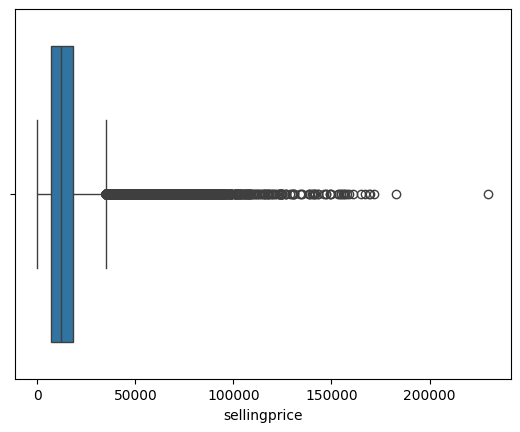

In [10]:
sns.boxplot(
    x=car_auction['sellingprice']
)

plt.show()

In [11]:
Q1 = car_auction['sellingprice'].quantile(0.25)

Q3 = car_auction['sellingprice'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

car_auction = car_auction[
    (car_auction['sellingprice'] >= lower) &
    (car_auction['sellingprice'] <=upper)
]

In [12]:
car_auction.duplicated().sum()

np.int64(0)

In [13]:
car_auction["condition_category"] = pd.cut(
    car_auction["condition"],
    bins=[0, 2, 4, 5],
    labels=["low", "medium", "high"]
)

In [14]:
car_auction["vehicle_age"] = 2026 - car_auction["year"]
car_auction["condition_per_age"] = (
    car_auction["condition"] / car_auction["vehicle_age"]
)

In [15]:
luxury_brands = ["bmw", "audi", "mercedes-benz", "lexus"]

car_auction["is_luxury"] = (
    car_auction["make"].isin(luxury_brands)
).astype(int)

In [16]:
premium_words = ["sport", "limited", "touring", "premium", "lx", "ex"]

car_auction["premium_trim"] = (
    car_auction["trim"]
    .str.contains("|".join(premium_words), case=False, na=False)
).astype(int)

In [17]:
# Vehicle age
car_auction["vehicle_age"] = 2026 - car_auction["year"]

# Per year usage
car_auction["usage_intensity"] = (
    car_auction["odometer"] / car_auction["vehicle_age"]
)

# High mileage car
car_auction["high_mileage"] = (
    car_auction["odometer"] > 100000
).astype(int)

# Low mileage car
car_auction["low_mileage"] = (
    car_auction["odometer"] < 50000
).astype(int)


# Condition vs mileage
car_auction["condition_odometer_ratio"] = (
    car_auction["condition"] /
    (car_auction["odometer"] + 1)
)

# Mileage 
car_auction["odometer_bucket"] = pd.cut(
    car_auction["odometer"],
    bins=[0, 50000, 100000, 150000, 300000],
    labels=["low", "medium", "high", "very_high"]
)

## MODEL TRAINING 

In [18]:
from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_percentage_error
import pandas as pd
import numpy as np
import joblib


# FEATURE

CAT_FEATURES = [
    "make",
    "model",
    "trim",
    "body",
    "state",
    "color",
    "interior",
    "transmission"
]

NUM_FEATURES = [
    "year",
    "condition",
    "odometer"
]


# CLEANING


for col in CAT_FEATURES:

    car_auction[col] = (
        car_auction[col]
        .fillna("unknown")
        .astype(str)
        .str.lower()
        .str.strip()
    )

for col in NUM_FEATURES:

    car_auction[col] = (
        car_auction[col]
        .fillna(
            car_auction[col].median()
        )
    )


# FEATURE ENGINEERING


BASE_YEAR = 2025

car_auction["vehicle_age"] = (
    BASE_YEAR - car_auction["year"]
)

car_auction["usage_intensity"] = (
    car_auction["odometer"] /
    car_auction["vehicle_age"].clip(lower=1)
)

car_auction["age_x_mileage"] = (
    car_auction["vehicle_age"] *
    car_auction["odometer"]
)


# FINAL FEATURES


FEATURES = [

    "year",
    "condition",
    "odometer",

    "vehicle_age",
    "usage_intensity",
    "age_x_mileage",

    "make",
    "model",
    "trim",
    "body",
    "state",
    "color",
    "interior",
    "transmission"
]


# CATEGORY TYPE


for col in CAT_FEATURES:

    car_auction[col] = (
        car_auction[col]
        .astype("category")
    )


# FEATURES + TARGET


X = car_auction[FEATURES]

y = np.log1p(
    car_auction["sellingprice"]
)


# TRAIN TEST SPLIT


X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)


# LIGHTGBM MODEL


model = LGBMRegressor(

    n_estimators=300,

    learning_rate=0.05,

    num_leaves=127,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    n_jobs=-1

)


# TRAIN MODEL


print("Training Model...")

model.fit(

    X_train,

    y_train,

    categorical_feature=CAT_FEATURES

)

print("Training Complete")


# PREDICTION


y_pred_log = model.predict(X_test)

y_pred = np.expm1(y_pred_log)

y_true = np.expm1(y_test)


# EVALUATION


mape = mean_absolute_percentage_error(
    y_true,
    y_pred
)

mae = np.mean(
    np.abs(y_true - y_pred)
)

r2 = model.score(X_test, y_test)

print("\n=== MODEL EVALUATION ===")

print(f"MAPE : {mape:.4f}")

print(f"MAE : ${mae:.2f}")

print(f"R² Score : {r2:.4f}")


# SAVE MODEL


joblib.dump(
    model,
    "model_Abhishek.pkl"
)

print("Model Saved Successfully")

Training Model...
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008592 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2281
[LightGBM] [Info] Number of data points in the train set: 347084, number of used features: 14
[LightGBM] [Info] Start training from score 9.161138
Training Complete

=== MODEL EVALUATION ===
MAPE : 0.1389
MAE : $1059.69
R² Score : 0.9404
Model Saved Successfully


In [19]:
from sklearn.model_selection import RandomizedSearchCV


# PARAMETER GRID


param_grid = {

    "n_estimators": [200, 300, 500],

    "learning_rate": [0.01, 0.03, 0.05],

    "num_leaves": [63, 127, 255],

    "subsample": [0.7, 0.8, 1.0],

    "colsample_bytree": [0.7, 0.8, 1.0]

}


# RANDOM SEARCH


random_search = RandomizedSearchCV(

    estimator=model,

    param_distributions=param_grid,

    n_iter=10,

    scoring="neg_mean_absolute_percentage_error",

    cv=3,

    verbose=2,

    random_state=42,

    n_jobs=1

)

print("Starting Hyperparameter Tuning...")

random_search.fit(

    X_train,

    y_train,

    categorical_feature=CAT_FEATURES

)

print("Tuning Complete")


# BEST MODEL


best_model = random_search.best_estimator_

print("\nBest Parameters:")

print(random_search.best_params_)


# PREDICTION


y_pred_log = best_model.predict(X_test)

y_pred = np.expm1(y_pred_log)

y_true = np.expm1(y_test)


# FINAL METRICS


mape = mean_absolute_percentage_error(
    y_true,
    y_pred
)

mae = np.mean(
    np.abs(y_true - y_pred)
)

r2 = best_model.score(X_test, y_test)

print("\n=== TUNED MODEL RESULTS ===")

print(f"MAPE : {mape:.4f}")

print(f"MAE : ${mae:.2f}")

print(f"R² Score : {r2:.4f}")


# SAVE BEST MODEL


joblib.dump(
    best_model,
    "model_Abhishek.pkl"
)


print("Best Model Saved")

Starting Hyperparameter Tuning...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014763 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2289
[LightGBM] [Info] Number of data points in the train set: 231389, number of used features: 14
[LightGBM] [Info] Start training from score 9.159804
[CV] END colsample_bytree=0.7, learning_rate=0.01, n_estimators=500, num_leaves=255, subsample=0.7; total time=  13.5s
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of te

In [20]:

# MODEL COMPARISON


baseline_mape = 0.20   # OLD RandomForest approx value

tuned_mape = mape

comparison = pd.DataFrame({

    "Model": [

        "Old RandomForest",

        "Optimized LightGBM"

    ],

    "MAPE": [

        baseline_mape,

        tuned_mape

    ]

})

comparison["MAPE"] = (
    comparison["MAPE"] * 100
)

print("\n=== MODEL COMPARISON ===")

print(comparison)


=== MODEL COMPARISON ===
                Model       MAPE
0    Old RandomForest  20.000000
1  Optimized LightGBM  13.736219
